<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Escorrentía

## Objetivo




# 1. Configuración del entorno

## 1.1 Clonar el repositorio desde GitHub

Para acceder a los datos y scripts del curso, clonaremos el repositorio desde GitHub. Esto descarga todos los archivos necesarios en el entorno de Google Colab.

> ⚠️ **Nota:** Esta celda solo debe ejecutarse **una vez** por sesión. Si el repositorio ya fue clonado, puedes omitir este paso.

In [14]:
# Clona el repositorio del curso desde GitHub en el entorno de Google Colab.
import os
REPO_URL = "https://github.com/paulmunozpauta/Hidrology_Course"
REPO_BRANCH = "main"
REPO_DIR = "/content/Hidrology_Course"
# Clone or update repo
if not os.path.exists(REPO_DIR):
    !git clone --branch $REPO_BRANCH $REPO_URL $REPO_DIR
else:
    %cd $REPO_DIR
    !git pull


/content/Hidrology_Course
Already up to date.


Después de ejecutar la celda anterior, se crea una carpeta llamada **`Hidrology_Course`** en el entorno de trabajo. Esta carpeta contiene todos los archivos del curso, incluyendo los datos pluviométricos que usaremos a continuación.

## 1.2 Ingresar a la carpeta del repositorio

Cambiamos el directorio de trabajo para que Python pueda encontrar los archivos de datos mediante rutas relativas.

# Entrar a la carpeta del repositorio





In [15]:
# Cambia el directorio de trabajo actual a la carpeta del repositorio clonado.
# El comando mágico %cd de Jupyter/Colab cambia el directorio de forma persistente
%cd Hidrology_Course
# Muestra los archivos disponibles en la carpeta actual para verificar
# que el repositorio se clonó correctamente.
!ls

[Errno 2] No such file or directory: 'Hidrology_Course'
/content/Hidrology_Course
01_Delimitacion_cuenca.ipynb	   03_Precipitación.ipynb  Data       Static
02_Probabilidad_estadística.ipynb  04_Escorrentía.ipynb    README.md



# 2. Instalación e importación de librerías

Las siguientes librerías son fundamentales para el análisis hidrológico en Python:

| Librería | Uso principal en este notebook |
|----------|--------------------------------|
| `pandas` | Manejo de series de tiempo y DataFrames |
| `numpy` | Operaciones numéricas y manejo de valores nulos |
| `matplotlib` | Visualización de datos (gráficos y figuras) |
| `os` | Interacción con el sistema de archivos |



Librerías principales:
pandas
numpy
matplotlib

In [16]:
# Instala (o actualiza) la librería pandas desde PyPI.
!pip install -q pandas

In [17]:
# os: permite interactuar con rutas y directorios del sistema operativo.
import os
# numpy: librería de computación numérica. Se usa para operaciones vectoriales
# y para trabajar con valores nulos (np.nan).
import numpy as np
# matplotlib.pyplot: módulo de visualización. Permite crear gráficos de líneas,
# barras, dispersión, etc.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# pandas: librería principal para análisis de datos tabulares y series de tiempo.
# Se usará para leer los archivos Excel y manipular los datos pluviométricos.
import pandas as pd
import random
import math
import struct



# 3. Lectura de datos hidrometeorológicos

## Estación Renegado en Invernada – DGA (código 08130001-1)

<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Data/Caudal/CuencasNuble.png" width="500">
</p>

Trabajaremos con datos de la estación **xx**, ubicada en la Región xxx. Esta estación pertenece a la red de la Dirección General de Aguas (DGA) de Chile.

El Río Diguillín nace en la parte suroeste de los Nevados de Chillán, a una
altitud de 2000 msnm. Entre los afluentes más significativos al Rio Diguillín se encuentra el Río
Renegado, el cual tiene su nacimiento al suroeste de los Nevado de Chillán, a
una altitud de 1.722 msnm. La cuenca del Río
Renegado posee una superficie de 128,6 km2
, una pendiente media del 17,8%
y una elevación media de 1553 msnm, en la zona se alcanzan temperaturas
medias anuales de 8,1 °C, precipitaciones medias anuales de 2533 mm y un
caudal medio anual de 2,6 m3 s
-1
, además, en esta zona predominan las
unidades geológicas de Piroclástico y roca volcánica básica.

**Formato de los datos DGA:**

Los archivos descargados del explorador del CR2 (https://explorador.cr2.cl/) suelen tener columnas separadas para año (`agno`), mes (`mes`), día (`dia`) y valor de precipitación diaria (`valor`), en lugar de una columna de fecha completa. Este formato requiere un paso de preprocesamiento que veremos a continuación.

**Cuenca hidrohráfica asociada**
Río Renegado
En Invernada 128,6km2,  1553 cota media, 17,8 pendiente media

precipitacion media anual 2533 mm,  8,1 C temperatura media, ycudal medio anual 2,6 m3/s


In [18]:
# Define la ruta relativa al archivo de datos de la estación Puerto Montt.
# Al haber cambiado el directorio con %cd, la ruta parte desde la raíz del repositorio.
archivo = "Data/Caudal/DGA_08130001-1_Renegado-Invernada.xlsx"

# Lee el archivo Excel y carga los datos en un DataFrame de pandas.
# Un DataFrame es una tabla bidimensional con filas y columnas etiquetadas.
RInv = pd.read_excel(archivo)

# Muestra las primeras filas del DataFrame para verificar la estructura de los datos.
print(f"Dimensiones del dataset: {RInv.shape[0]} filas × {RInv.shape[1]} columnas\n")
RInv.tail(10)

Dimensiones del dataset: 25439 filas × 4 columnas



,agno,mes,dia,valor
25429,2019,12,21,0.1
25430,2019,12,22,0.1
25431,2019,12,23,0.1
25432,2019,12,24,0.1
25433,2019,12,25,0.1
25434,2019,12,26,0.1
25435,2019,12,27,0.1
25436,2019,12,28,0.1
25437,2019,12,29,0.1
25438,2019,12,30,0.1



# 4. Preprocesamiento de datos

## ¿Por qué es necesario el preprocesamiento?

Los datos crudos de la DGA presentan varias situaciones que deben resolverse antes de cualquier análisis:

1. **Columnas separadas de año, mes y día:** Deben unirse para formar una fecha válida.
2. **Nombres de columnas inconsistentes:** Pueden tener espacios, acentos o variaciones    ortográficas según la versión del archivo.
3. **Valores no numéricos:** Algunos registros pueden contener texto (e.g., códigos de error).    Se deben convertir a numérico, forzando los no válidos a `NaN`.
4. **Fechas inválidas:** Por ejemplo, el 31 de febrero, que no existe. Deben eliminarse.
5. **Ordenamiento temporal:** Los datos deben estar ordenados cronológicamente.

El preprocesamiento es un paso crítico en hidrología: datos mal formateados pueden producir errores en cálculos estadísticos, análisis de frecuencia y diseño hidrológico.

Los datos diarios de esta estación están separados en columnas por "agno", "mes", "día" y "valor".

Vamos a generar una serie (dataframe) ordenada cronológicamente a través de la fecha disponible

In [19]:
# limpiar nombres de columnas
RInv.columns = RInv.columns.str.strip().str.lower()

# renombrar por seguridad si vienen con espacios o acentos raros
RInv = RInv.rename(columns={
    "agno": "anio",
    "año": "anio",
    "mes": "mes",
    "dia": "dia",
    "valor": "caudal_diario_m3_s"
})

# convertir columnas a numéricas
for col in ["anio", "mes", "dia", "caudal_diario_m3_s"]:
    RInv[col] = pd.to_numeric(RInv[col], errors="coerce")

# eliminar filas con datos faltantes en columnas clave
RInv = RInv.dropna(subset=["anio", "mes", "dia", "caudal_diario_m3_s"])

# convertir año, mes y día a enteros
RInv["anio"] = RInv["anio"].astype(int)
RInv["mes"] = RInv["mes"].astype(int)
RInv["dia"] = RInv["dia"].astype(int)

# crear columna fecha
RInv["fecha"] = pd.to_datetime(
    dict(year=RInv["anio"], month=RInv["mes"], day=RInv["dia"]),
    errors="coerce"
)

# eliminar fechas inválidas
RInv = RInv.dropna(subset=["fecha"])

# dejar solo la serie temporal final
RInv = RInv[["fecha", "caudal_diario_m3_s"]].copy()

# ordenar por fecha
RInv = RInv.sort_values("fecha").reset_index(drop=True)

# opcional: usar fecha como índice
RInv = RInv.set_index("fecha")

# mostrar la serie
RInv


,caudal_diario_m3_s
fecha,
1940-03-01,2.6
1940-03-02,2.6
1940-03-03,2.6
1940-03-04,2.6
1940-03-05,2.6
...,...
2019-12-26,0.1
2019-12-27,0.1
2019-12-28,0.1


# 5. Visualización de la serie de caudal diario

Antes de realizar cualquier análisis, es fundamental **visualizar los datos** para:
- Detectar tendencias generales y estacionalidad.
- Identificar posibles errores o datos atípicos (*outliers*).



<Figure size 1200x500 with 0 Axes>

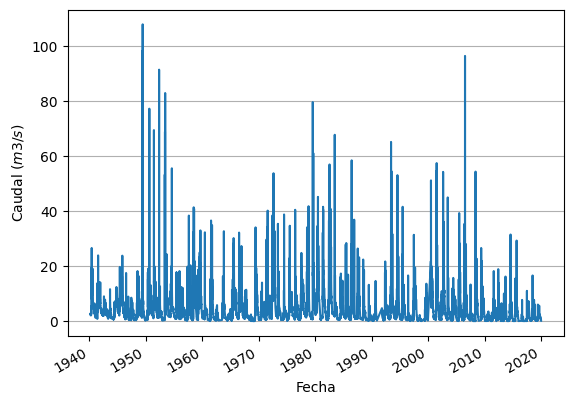

In [20]:
plt.figure(figsize=(12,5))
RInv.plot(legend=False)#no lo hacemos como barras por la carga computacional
plt.xlabel("Fecha")
plt.ylabel("Caudal ($m3/s$)")
plt.grid(axis="y")
plt.show()

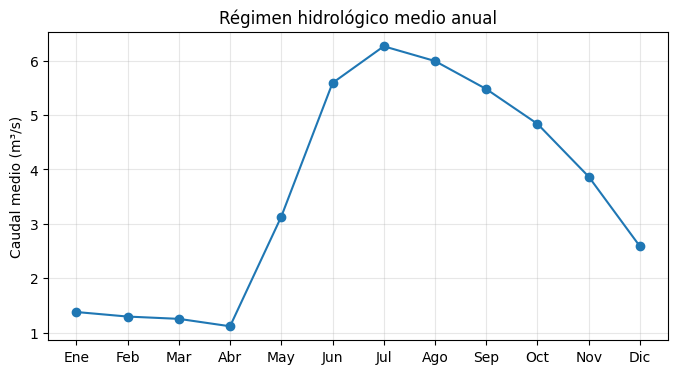

In [21]:
monthly = RInv.groupby(RInv.index.month)["caudal_diario_m3_s"].mean()

meses = ["Ene","Feb","Mar","Abr","May","Jun",
         "Jul","Ago","Sep","Oct","Nov","Dic"]

plt.figure(figsize=(8,4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.xticks(range(1,13), meses)
plt.ylabel("Caudal medio (m³/s)")
plt.title("Régimen hidrológico medio anual")
plt.grid(alpha=0.3)
plt.show()

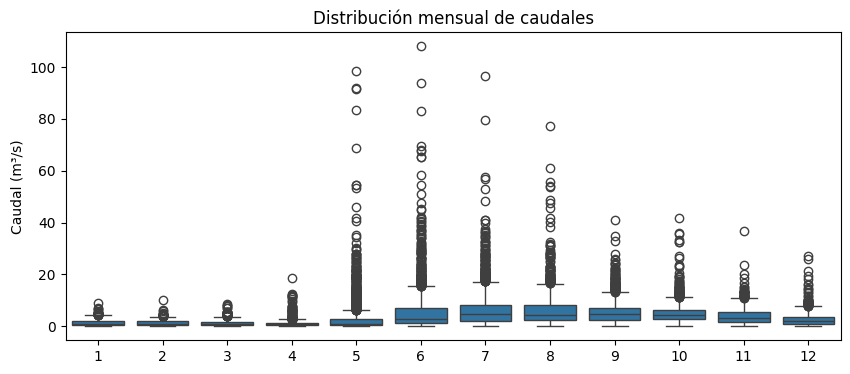

In [22]:
import seaborn as sns

RInv["mes"] = RInv.index.month

plt.figure(figsize=(10,4))
sns.boxplot(data=RInv,
            x="mes",
            y="caudal_diario_m3_s")

plt.ylabel("Caudal (m³/s)")
plt.xlabel("")
plt.title("Distribución mensual de caudales")
plt.show()

/tmp/ipykernel_3616/3489544959.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = RInv.resample("Y").mean()


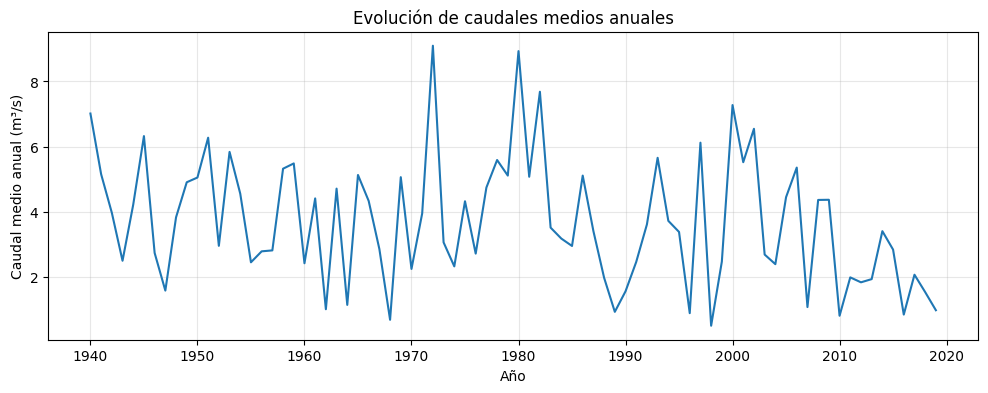

In [23]:
annual = RInv.resample("Y").mean()

plt.figure(figsize=(12,4))
plt.plot(annual.index.year,
         annual["caudal_diario_m3_s"])

plt.ylabel("Caudal medio anual (m³/s)")
plt.xlabel("Año")
plt.title("Evolución de caudales medios anuales")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_3616/2002433282.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_max = RInv.resample("Y").max()


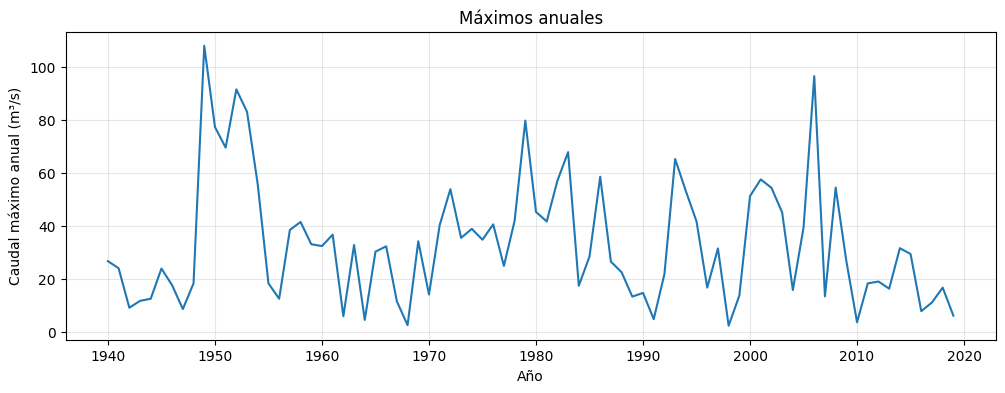

In [24]:
annual_max = RInv.resample("Y").max()

plt.figure(figsize=(12,4))
plt.plot(annual_max.index.year,
         annual_max["caudal_diario_m3_s"])

plt.ylabel("Caudal máximo anual (m³/s)")
plt.xlabel("Año")
plt.title("Máximos anuales")
plt.grid(alpha=0.3)
plt.show()

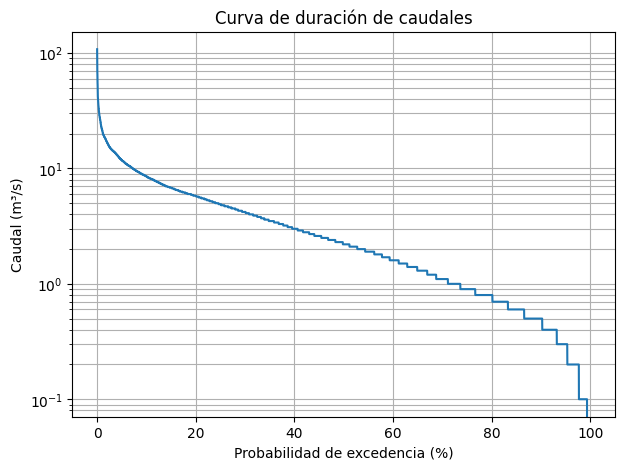

In [25]:
import numpy as np

Q = np.sort(
    RInv["caudal_diario_m3_s"].dropna()
)[::-1]

P = 100*np.arange(1,len(Q)+1)/(len(Q)+1)

plt.figure(figsize=(7,5))
plt.semilogy(P,Q)
plt.xlabel("Probabilidad de excedencia (%)")
plt.ylabel("Caudal (m³/s)")
plt.title("Curva de duración de caudales")
plt.grid(True, which="both")
plt.show()

In [26]:
Qmean = RInv["caudal_diario_m3_s"].mean()

Q5 = RInv["caudal_diario_m3_s"].quantile(0.95)
Q50 = RInv["caudal_diario_m3_s"].quantile(0.50)
Q95 = RInv["caudal_diario_m3_s"].quantile(0.05)

Qmax = RInv["caudal_diario_m3_s"].max()
Qmin = RInv["caudal_diario_m3_s"].min()

CV = (RInv["caudal_diario_m3_s"].std()/Qmean)*100

# Crear tabla resumen

summary = pd.DataFrame({
    "Indicador": [
        "Caudal medio (Qmean)",
        "Caudal máximo",
        "Caudal mínimo",
        "Q5",
        "Q50",
        "Q95",
        "Coeficiente de variación (%)"
    ],
    "Valor": [
        Qmean,
        Qmax,
        Qmin,
        Q5,
        Q50,
        Q95,
        CV
    ]
})

summary["Valor"] = summary["Valor"].round(2)

summary

,Indicador,Valor
0,Caudal medio (Qmean),3.74
1,Caudal máximo,108.00
2,Caudal mínimo,0.00
3,Q5,11.80
4,Q50,2.20
5,Q95,0.30
6,Coeficiente de variación (%),131.13
